In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "aiconfigurator").exists():
    REPO_ROOT = Path.cwd().parent

RUN_ROOT = REPO_ROOT / "fpm_golden_runs" / "fpm_upfront_qwen36_moe_full_once_20260613_201336"
MODEL = "Qwen/Qwen3.6-35B-A3B"

CASE_RE = re.compile(r"^tp(?P<tp>\d+)_ep(?P<ep>\d+)_past(?P<past_kv>\d+)$")


def load_fpm_case(case_dir: Path) -> dict:
    phase_csv = case_dir / "fpm_metrics_phase.csv"
    if not phase_csv.exists():
        raise FileNotFoundError(f"missing {phase_csv}")

    match = CASE_RE.match(case_dir.name)
    if match is None:
        raise ValueError(f"unexpected case directory name: {case_dir.name}")

    phase = pd.read_csv(phase_csv)
    metrics = pd.read_csv(case_dir / "fpm_metrics.csv")
    detail = pd.read_csv(case_dir / "fpm_metrics_detail.csv")
    request_workload = pd.read_csv(case_dir / "request_workload.csv")
    warmup_workload = pd.read_csv(case_dir / "warmup_workload.csv")

    with (case_dir / "effective_vllm_config.json").open() as f:
        effective_config = json.load(f)
    with (case_dir / "vllm_metadata.json").open() as f:
        metadata = json.load(f)

    meta = {
        "case": case_dir.name,
        "model": MODEL,
        "tp_size": int(match.group("tp")),
        "ep_size": int(match.group("ep")),
        "decode_past_kv": int(match.group("past_kv")),
        "path": case_dir,
    }
    for frame in (phase, metrics, detail, request_workload, warmup_workload):
        for key, value in meta.items():
            if key != "path":
                frame[key] = value

    return {
        **meta,
        "phase": phase,
        "metrics": metrics,
        "detail": detail,
        "request_workload": request_workload,
        "warmup_workload": warmup_workload,
        "effective_config": effective_config,
        "metadata": metadata,
    }


case_dirs = sorted(RUN_ROOT.glob("tp*_ep*_past*"))
cases = []
for case_dir in case_dirs:
    try:
        cases.append(load_fpm_case(case_dir))
    except FileNotFoundError as exc:
        print(f"skip {case_dir.name}: {exc}")

fpm_phase = pd.concat([case["phase"] for case in cases], ignore_index=True)
fpm_metrics = pd.concat([case["metrics"] for case in cases], ignore_index=True)
cases_by_name = {case["case"]: case for case in cases}

print(f"loaded {len(cases)} cases from {RUN_ROOT}")
print("cases:", ", ".join(case["case"] for case in cases))
print()
print("phase rows by case / segment / phase:")
print(
    fpm_phase.groupby(["case", "workload_segment", "phase"], dropna=False)
    .size()
    .unstack(fill_value=0)
)
print()
fpm_phase.head()


skip tp8_ep1_past4096: missing /Users/simonec/repo/aic/aiconfigurator/fpm_golden_runs/fpm_upfront_qwen36_moe_full_once_20260613_201336/tp8_ep1_past4096/fpm_metrics_phase.csv
loaded 6 cases from /Users/simonec/repo/aic/aiconfigurator/fpm_golden_runs/fpm_upfront_qwen36_moe_full_once_20260613_201336
cases: tp1_ep1_past4096, tp2_ep1_past4096, tp2_ep2_past4096, tp4_ep1_past4096, tp4_ep4_past4096, tp8_ep8_past4096

phase rows by case / segment / phase:
phase                              context  decode  mixed
case             workload_segment                        
tp1_ep1_past4096 real                    3    6043    187
                 sweep                  63     185     95
tp2_ep1_past4096 real                    2    6154    187
                 sweep                  61     192    108
tp2_ep2_past4096 real                    1    6254    192
                 sweep                  61     181    107
tp4_ep1_past4096 real                    3    6364    191
                 sweep     

,phase,workload_segment,counter_id,worker_id,dp_rank,ctx_tokens,ctx_requests,ctx_kv_tokens,decode_tokens,decode_requests,...,queued_ctx_tokens,queued_ctx_requests,queued_decode_requests,queued_decode_kv_tokens,latency_ms,case,model,tp_size,ep_size,decode_past_kv
0,context,sweep,1059,1.201672e+19,0,128,1,0,0,0,...,0,0,0,0,19.998,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
1,context,sweep,1060,1.201672e+19,0,1024,1,0,0,0,...,0,0,0,0,38.538,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
2,context,sweep,1061,1.201672e+19,0,3168,1,0,0,0,...,0,0,0,0,78.913,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
3,context,sweep,1062,1.201672e+19,0,928,1,3168,0,0,...,0,0,0,0,0.348,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
4,context,sweep,1063,1.201672e+19,0,128,1,0,0,0,...,0,0,0,0,14.916,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096


In [26]:
fpm_metrics.head()

,num_context_tokens,num_decode_tokens,latency_ms,case,model,tp_size,ep_size,decode_past_kv
0,128,0,19.998,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
1,1024,0,38.538,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
2,3168,0,78.913,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
3,928,0,0.348,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096
4,128,0,14.916,tp1_ep1_past4096,Qwen/Qwen3.6-35B-A3B,1,1,4096


In [38]:
# Analayze artificial workload from "sweep"
print("2 types of workloads:", fpm_phase["workload_segment"].unique().tolist())

data0 = fpm_phase[fpm_phase["workload_segment"] == "sweep"]
print("sweep rows:", len(data0))
print(data0.groupby("phase").size())
print()

data1 = fpm_phase[fpm_phase["workload_segment"] == "real"]
print("real rows:", len(data1))
print(data1.groupby("phase").size())

# Get the number of rows in each phase

2 types of workloads: ['sweep', 'real']
sweep rows: 2138
phase
context     389
decode     1126
mixed       623
dtype: int64

real rows: 38827
phase
context       12
decode     37656
mixed       1159
dtype: int64


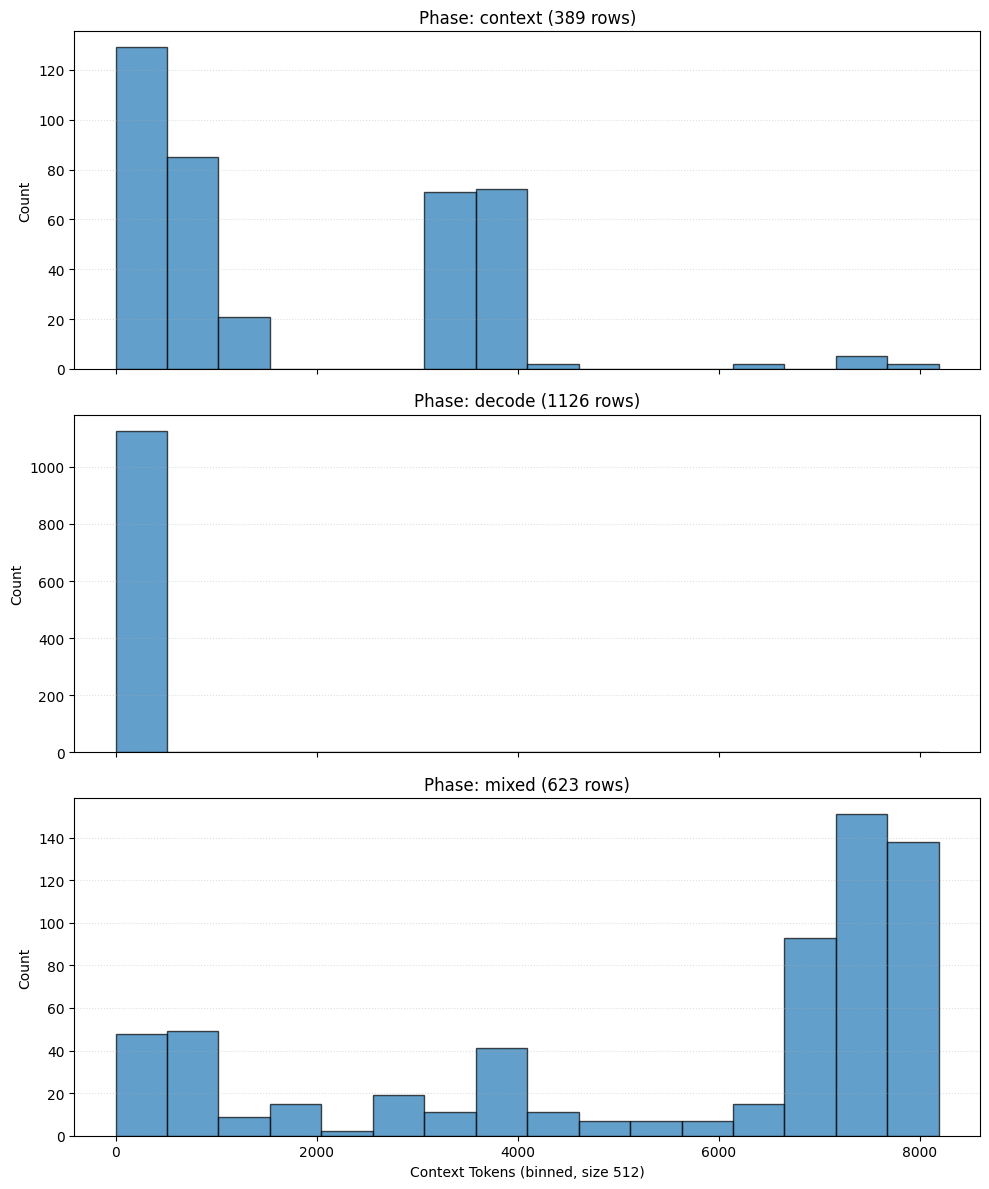

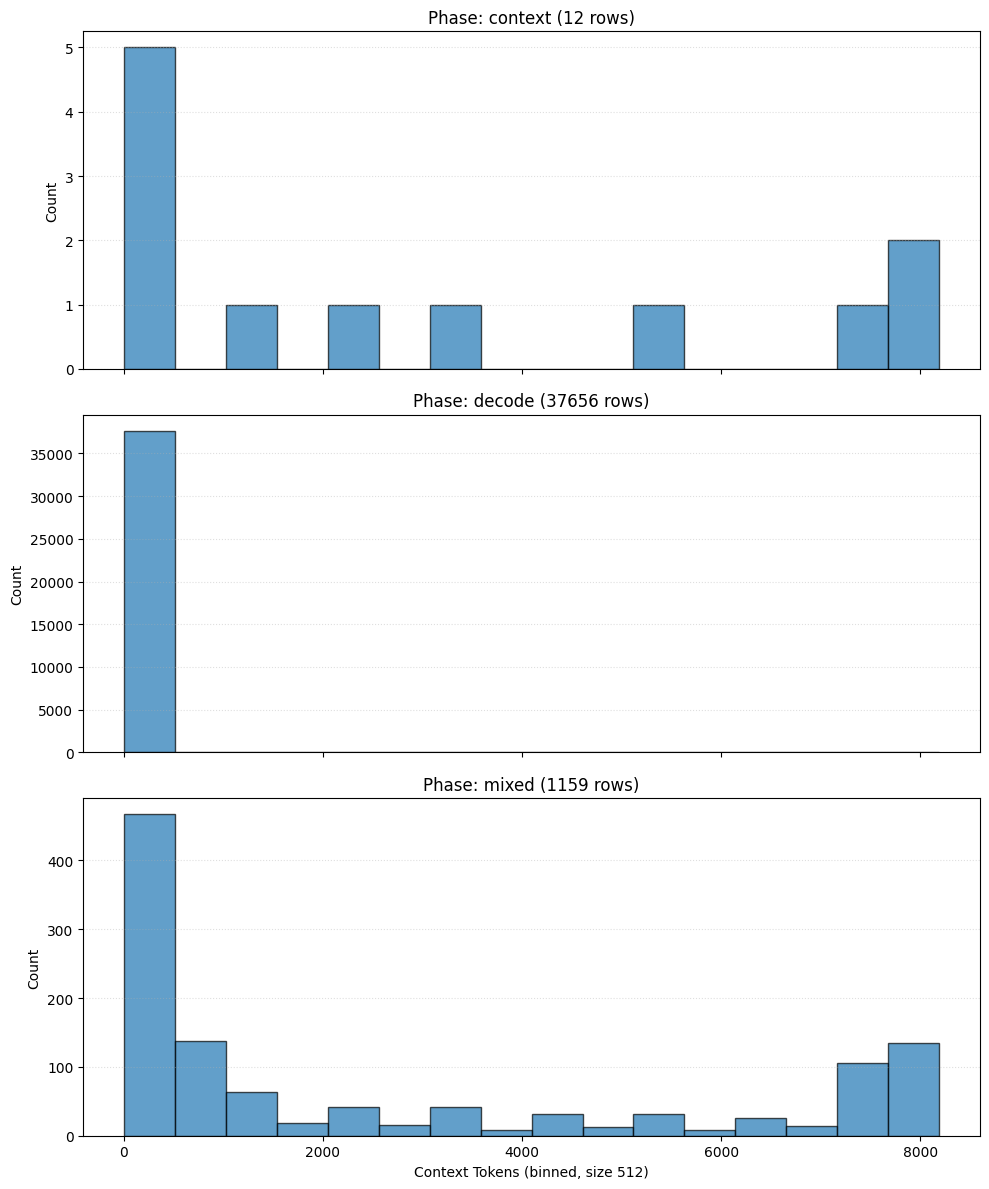

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ctx_tokens_histogram(data, bin_size=512):
    import math

    phases = sorted(data["phase"].unique())
    n_phases = len(phases)

    ctx_min = data["ctx_tokens"].min()
    ctx_max = data["ctx_tokens"].max()
    bins = np.arange(ctx_min, ctx_max + bin_size, bin_size)

    # Set up subplots, 1 row per phase
    fig, axs = plt.subplots(n_phases, 1, figsize=(10, 4 * n_phases), sharex=True)

    # axs is a single Axes object if only one phase - force to list for uniformity
    if n_phases == 1:
        axs = [axs]

    for ax, phase in zip(axs, phases):
        group = data[data["phase"] == phase]
        ax.hist(
            group["ctx_tokens"], bins=bins, alpha=0.7, edgecolor='black'
        )
        ax.set_title(f"Phase: {phase} ({len(group)} rows)")
        ax.set_ylabel("Count")
        ax.grid(axis='y', linestyle=':', alpha=0.4)

    axs[-1].set_xlabel("Context Tokens (binned, size %d)" % bin_size)
    plt.tight_layout()
    plt.show()

# Call the function
plot_ctx_tokens_histogram(data0, bin_size=512)
plot_ctx_tokens_histogram(data1, bin_size=512)


In [54]:
import sys
import tempfile

sys.path.insert(0, str(REPO_ROOT / "collector" / "layerwise" / "diagnostics"))

from compare_aic_layerwise_fpm import (  # noqa: E402
    _resolve_auto_max_num_batched_tokens,
    compare,
)

LAYERWISE_CSV = REPO_ROOT / "src/aiconfigurator/systems/data/b300_sxm/vllm/0.20.1/layerwise_perf.csv"
SYSTEMS_ROOT = REPO_ROOT / "src/aiconfigurator/systems"
MOE_PERF_OVERLAY_CANDIDATES = (
    REPO_ROOT / "runs/combined_moe_ops_overlay_with_eager_20260613/moe_perf.txt",
    REPO_ROOT / "collector/layerwise/wip/moe_perf.txt",
)
MOE_PERF_FILE = next((path for path in MOE_PERF_OVERLAY_CANDIDATES if path.is_file()), None)


def resolve_moe_parallelism(tp_size: int, ep_size: int) -> tuple[int, int]:
    """Map FPM case TP/EP to AIC (moe_tp, ep)."""

    if ep_size == 1 and tp_size > 1:
        return tp_size, 1
    return 1, ep_size


def case_aic_parallelism(tp_size: int, ep_size: int) -> tuple[int, int, int]:
    """Return (tp, moe_tp, ep) for one FPM case directory."""

    moe_tp, ep = resolve_moe_parallelism(tp_size, ep_size)
    return tp_size, moe_tp, ep


def compare_cases_to_aic_fpm(
    cases_by_name: dict[str, dict],
    *,
    case_names: list[str] | None = None,
    layerwise_csv: Path = LAYERWISE_CSV,
    systems_root: Path = SYSTEMS_ROOT,
    moe_perf_file: Path | None = MOE_PERF_FILE,
    model: str = MODEL,
    workload_segment: str = "sweep",
    aggregation: str = "trimmed_mean",
    decode_match: str = "pooled",
    decode_past_kv: int = 4096,
    decode_osl: int = 2,
    max_decode_kv_distance: float = 4.0,
    decode_pool_forward_window: float = 6.0,
    include_mixed: bool = False,
    moe_workload_distribution: str = "power_law",
) -> pd.DataFrame:
    """Run compare_aic_layerwise_fpm.compare() for each loaded FPM case."""

    selected = case_names or sorted(cases_by_name)
    rows: list[dict] = []
    with tempfile.TemporaryDirectory(prefix="qwen36_aic_fpm_") as tmpdir:
        tmp_path = Path(tmpdir)
        for case_name in selected:
            case = cases_by_name[case_name]
            fpm_csv = case["path"] / "fpm_metrics_phase.csv"
            tp, moe_tp, ep = case_aic_parallelism(case["tp_size"], case["ep_size"])
            max_num_batched_tokens = _resolve_auto_max_num_batched_tokens(
                layerwise_csv=layerwise_csv,
                fpm_csv=fpm_csv,
                model_name=model,
                tp=tp,
                moe_tp=moe_tp,
                ep=ep,
                workload_segment=workload_segment,
            )
            case_rows = compare(
                layerwise_csv=layerwise_csv,
                fpm_csv=fpm_csv,
                model_name=model,
                tp=tp,
                moe_tp=moe_tp,
                ep=ep,
                moe_workload_distribution=moe_workload_distribution,
                output=tmp_path / f"{case_name}.csv",
                filtered_output=tmp_path / f"{case_name}_filtered_rows.csv",
                aggregation=aggregation,
                decode_past_kv=decode_past_kv,
                decode_osl=decode_osl,
                decode_match=decode_match,
                max_decode_kv_distance=max_decode_kv_distance,
                decode_pool_forward_window=decode_pool_forward_window,
                include_mixed=include_mixed,
                vllm_max_num_batched_tokens=max_num_batched_tokens,
                vllm_max_num_seqs=None,
                filter_pathological_context=True,
                pathological_context_min_continuation_ctx_tokens=128,
                pathological_context_continuation_min_latency_ms=5.0,
                pathological_context_peer_min_count=3,
                pathological_context_high_latency_factor=3.0,
                filter_pathological_decode=True,
                pathological_decode_peer_kv_window=8.0,
                pathological_decode_peer_batch_window=2,
                pathological_decode_min_peer_count=1,
                pathological_decode_latency_factor=5.0,
                pathological_decode_min_latency_ms=20.0,
                filter_pathological_mixed=False,
                filter_mixed_below_decode_floor=True,
                filter_nonterminal_mixed_chunks=False,
                fpm_workload_segment=workload_segment,
                pathological_mixed_tiny_ctx_tokens=320,
                pathological_mixed_min_ctx_tokens=128,
                pathological_mixed_peer_ctx_fraction=0.05,
                pathological_mixed_peer_ctx_min_window=512,
                pathological_mixed_min_peer_count=3,
                pathological_mixed_latency_fraction=0.60,
                pathological_mixed_high_latency_factor=1.2,
                pathological_mixed_decode_spike_window=5,
                include_per_ops=False,
                systems_root=str(systems_root),
                moe_perf_file=moe_perf_file,
            )
            for row in case_rows:
                signed_error_pct = float(row["error_pct"])
                rows.append(
                    {
                        "case": case_name,
                        "phase": row["phase"],
                        "tp_size": case["tp_size"],
                        "ep_size": case["ep_size"],
                        "tp": row["tp"],
                        "moe_tp": row["moe_tp"],
                        "ep": row["ep"],
                        "shape": row.get("shape"),
                        "ctx_tokens": row.get("ctx_tokens"),
                        "ctx_requests": row.get("ctx_requests"),
                        "ctx_prefix_tokens": row.get("ctx_prefix_tokens"),
                        "ctx_kv_tokens": row.get("ctx_kv_tokens"),
                        "decode_requests": row.get("decode_requests"),
                        "mean_decode_kv_tokens": row.get("mean_decode_kv_tokens"),
                        "aic_ms": row["aic_ms"],
                        "fpm_ms": row["fpm_ms"],
                        "signed_error_pct": signed_error_pct,
                        "abs_error_pct": abs(signed_error_pct),
                        "fpm_samples": row["fpm_samples"],
                        "fpm_match": row["fpm_match"],
                        "fpm_representative_decode_kv": row.get("fpm_representative_decode_kv"),
                        "aic_decode_past_kv": row.get("aic_decode_past_kv"),
                    }
                )
    return pd.DataFrame(rows)


def summarize_mape(comparison_df: pd.DataFrame, group_cols: list[str] | None = None) -> pd.DataFrame:
    """Summarize MAPE from a comparison table."""

    if comparison_df.empty:
        return comparison_df
    group_cols = group_cols or ["phase"]
    return (
        comparison_df.groupby(group_cols, dropna=False)
        .agg(
            rows=("abs_error_pct", "size"),
            mape_pct=("abs_error_pct", "mean"),
            median_abs_error_pct=("abs_error_pct", "median"),
            mean_signed_error_pct=("signed_error_pct", "mean"),
        )
        .reset_index()
        .sort_values(group_cols)
    )


def prepare_heatmap_frame(comparison_df: pd.DataFrame) -> pd.DataFrame:
    """Normalize comparison rows for MAPE heatmaps."""

    if comparison_df.empty:
        return comparison_df.copy()

    df = comparison_df.copy()
    for col in (
        "ctx_tokens",
        "ctx_requests",
        "ctx_prefix_tokens",
        "decode_requests",
        "mean_decode_kv_tokens",
        "fpm_representative_decode_kv",
        "aic_decode_past_kv",
    ):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    gen_shape = df["shape"].astype(str).str.extract(r"bs(?P<bs>\d+)_past(?P<kv>\d+)")
    gen_mask = df["phase"].eq("gen")
    if "decode_requests" in df.columns:
        df.loc[gen_mask & df["decode_requests"].isna(), "decode_requests"] = pd.to_numeric(
            gen_shape.loc[gen_mask, "bs"], errors="coerce"
        )
    else:
        df["decode_requests"] = pd.NA
        df.loc[gen_mask, "decode_requests"] = pd.to_numeric(gen_shape.loc[gen_mask, "bs"], errors="coerce")

    if "mean_decode_kv_tokens" not in df.columns:
        df["mean_decode_kv_tokens"] = pd.NA
    df.loc[gen_mask & df["mean_decode_kv_tokens"].isna(), "mean_decode_kv_tokens"] = df.loc[
        gen_mask, "fpm_representative_decode_kv"
    ].fillna(df.loc[gen_mask, "aic_decode_past_kv"])

    df["num_requests"] = pd.NA
    df.loc[df["phase"].eq("ctx"), "num_requests"] = df.loc[df["phase"].eq("ctx"), "ctx_requests"]
    df.loc[df["phase"].eq("mixed"), "num_requests"] = df.loc[df["phase"].eq("mixed"), "decode_requests"]
    df.loc[df["phase"].eq("gen"), "num_requests"] = df.loc[df["phase"].eq("gen"), "decode_requests"]

    df["token_axis"] = pd.NA
    df.loc[df["phase"].eq("ctx"), "token_axis"] = df.loc[df["phase"].eq("ctx"), "ctx_tokens"]
    df.loc[df["phase"].eq("mixed"), "token_axis"] = df.loc[df["phase"].eq("mixed"), "ctx_tokens"]
    df.loc[df["phase"].eq("gen"), "token_axis"] = df.loc[df["phase"].eq("gen"), "mean_decode_kv_tokens"].round()

    return df


def plot_mape_heatmaps(
    comparison_df: pd.DataFrame,
    *,
    case_name: str | None = None,
    ctx_prefix_only_zero: bool = True,
) -> None:
    """Plot MAPE heatmaps for context, mixed, and decode phases."""

    import matplotlib.pyplot as plt
    import seaborn as sns

    heatmap_df = prepare_heatmap_frame(comparison_df)
    if case_name is not None:
        heatmap_df = heatmap_df[heatmap_df["case"] == case_name]

    phase_specs = {
        "ctx": ("Context", "num_requests", "token_axis", "Context requests", "Context tokens (new)"),
        "mixed": ("Mixed", "num_requests", "token_axis", "Decode requests", "Context tokens (new)"),
        "gen": ("Decode", "num_requests", "token_axis", "Decode requests", "Decode KV tokens"),
    }

    for phase, (title, x_col, y_col, xlabel, ylabel) in phase_specs.items():
        phase_df = heatmap_df[heatmap_df["phase"] == phase].copy()
        if phase == "ctx" and ctx_prefix_only_zero and "ctx_prefix_tokens" in phase_df.columns:
            phase_df = phase_df[phase_df["ctx_prefix_tokens"].fillna(0) == 0]
        phase_df = phase_df.dropna(subset=[x_col, y_col, "abs_error_pct"])
        if phase_df.empty:
            print(f"No data for {title.lower()} heatmap.")
            continue

        pivot = phase_df.pivot_table(
            index=y_col,
            columns=x_col,
            values="abs_error_pct",
            aggfunc="mean",
        ).sort_index().sort_index(axis=1)

        plt.figure(figsize=(max(6, 0.6 * pivot.shape[1] + 2), max(4, 0.35 * pivot.shape[0] + 2)))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".1f",
            cmap="coolwarm",
            linewidths=0.5,
            cbar_kws={"label": "MAPE (%)"},
        )
        plt.title(f"MAPE heatmap: {title}")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.tight_layout()
        plt.show()


if MOE_PERF_FILE is not None:
    print(f"Using MoE perf overlay: {MOE_PERF_FILE}")
else:
    print("No run-local MoE overlay found; using repo moe_perf.parquet via vLLM backend.")


Using MoE perf overlay: /Users/simonec/repo/aic/aiconfigurator/collector/layerwise/wip/moe_perf.txt


Notes:

- Predictions use `collector/layerwise/diagnostics/compare_aic_layerwise_fpm.py` via `compare_cases_to_aic_fpm()`.
- AIC totals include layerwise backbone lookup plus MoE/router/dispatch/comm addbacks from the vLLM backend.
- Optional run-local MoE overlay: `runs/combined_moe_ops_overlay_with_eager_20260613/moe_perf.txt`. If absent, the repo `moe_perf.parquet` is used.
- FPM rows are filtered to `workload_segment="sweep"` and binned with `(ctx_tokens, ctx_prefix_tokens)` for context and pooled decode KV matching.
- Decode comparisons stay empty until Qwen3.6 GEN rows are recollected with deployment-parity timing (`execute_model_gpu` / `schedule_to_update`), because current repo GEN rows are `moe_weight_mode=noop` span data that the backend rejects.

In [ ]:
# Restrict to one case while iterating; set to None to compare all loaded cases.
CASE_FILTER = ["tp1_ep1_past4096"]

comparison = compare_cases_to_aic_fpm(
    cases_by_name,
    case_names=CASE_FILTER,
    workload_segment="real",
    decode_past_kv=4096,
    include_mixed=True,
)

case_name = CASE_FILTER[0] if CASE_FILTER else None
if case_name is not None:
    ctx128 = comparison[
        (comparison["case"] == case_name)
        & (comparison["phase"] == "ctx")
        & (comparison["ctx_tokens"] == 128)
        & (comparison["ctx_prefix_tokens"].fillna(0) == 0)
    ]
    if not ctx128.empty:
        row = ctx128.iloc[0]
        print(
            f"context tp1 ctx128: FPM={row['fpm_ms']:.3f} ms "
            f"({int(row['fpm_samples'])} samples, {row['fpm_match']}), "
            f"AIC={row['aic_ms']:.3f} ms"
        )

if comparison[comparison["phase"] == "gen"].empty:
    print(
        "\nNote: no decode (gen) rows matched. Repo Qwen3.6 GEN rows are "
        "moe_weight_mode=noop span timings; VLLMBackend rejects them until "
        "deployment-parity decode layerwise is collected."
    )

# print("\nOverall MAPE summary:")
# display(summarize_mape(comparison))
# print("\nPer-case MAPE summary:")
# display(summarize_mape(comparison, group_cols=["case", "phase"]))
# print(f"\nMatched {len(comparison)} sweep shapes")
# comparison.sort_values("abs_error_pct", ascending=False).head(12)

In [59]:
comparison

,case,phase,tp_size,ep_size,tp,moe_tp,ep,shape,ctx_tokens,ctx_requests,...,decode_requests,mean_decode_kv_tokens,aic_ms,fpm_ms,signed_error_pct,abs_error_pct,fpm_samples,fpm_match,fpm_representative_decode_kv,aic_decode_past_kv
0,tp1_ep1_past4096,ctx,1,1,1,1,1,ctx128,128,1,...,None,None,37.052185,14.9110,148.488934,148.488934,6,exact,None,None
1,tp1_ep1_past4096,ctx,1,1,1,1,1,ctx1024,1024,1,...,None,None,217.939308,34.9635,523.333784,523.333784,6,exact,None,None


In [62]:
# MAPE heatmaps: x = number of requests, y = token axis (ctx_tokens or decode KV).
plot_mape_heatmaps(comparison, case_name=CASE_FILTER[0] if CASE_FILTER else None)

KeyError: 'case'